# Paper Figures: LLM vs Human Advice Analysis

This notebook generates all figures for the paper. Run cells sequentially.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats
import json

# Publication settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# Paths
DATA_DIR = Path('../data')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Grayscale palette
COLORS = {
    'human': '#222222',
    'deepseek': '#555555',
    'gemini': '#777777',
    'gpt_nano': '#999999',
    'ministral': '#bbbbbb',
}

SOURCE_LABELS = {
    'human': 'Human',
    'deepseek': 'DeepSeek',
    'gemini': 'Gemini',
    'gpt_nano': 'GPT-nano',
    'ministral': 'Ministral',
}

print('Setup complete')

Setup complete


## Load Data

In [28]:
# Load advice metrics
metrics_files = sorted(DATA_DIR.glob('advice_metrics/*.parquet'))
metrics = pd.read_parquet(metrics_files[-1])
print(f'Loaded metrics: {len(metrics)} rows')

# Load norm enforcement
norm_df = pd.read_csv(DATA_DIR / 'topic_norm_enforcement.csv')
print(f'Loaded norm enforcement: {len(norm_df)} topics')

# Load topic assignments
topics_df = pd.read_parquet(
    DATA_DIR / 'topic_assignment/posts_with_topics_google_gemini-2.5-flash-lite_20260121_094411.parquet',
    columns=['id', 'primary_topic', 'post_id']
)
topics_df['post_id'] = topics_df['post_id'].fillna(topics_df['id'])
post_topics = dict(zip(topics_df['post_id'], topics_df['primary_topic']))
metrics['topic'] = metrics['post_id'].map(post_topics)
print(f'Added topics to metrics')

Loaded metrics: 69496 rows
Loaded norm enforcement: 66 topics
Added topics to metrics


## Helper Functions

In [29]:
def cohens_d(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    if pooled_std == 0:
        return 0
    return (group1.mean() - group2.mean()) / pooled_std

def clean_topic_name(name):
    """Convert topic_name to Title Case."""
    return name.replace('_', ' ').title()

print('Helper functions defined')

Helper functions defined


---
## Figure 1: Assignment Bias Comparison

Model-specific assignment biases for high-variance topics.

In [30]:
# Load multi-model assignment data
multi_model_path = DATA_DIR / 'multi_model_assignment/multi_model_assignments_20260122_215645.parquet'
multi_df = pd.read_parquet(multi_model_path)

# Define model column mappings
model_columns = {
    'deepseek': 'deepseek-deepseek-chat-v3-0324_primary_topic',
    'gemini': 'gemini-2-5-flash-lite_primary',
    'gpt_nano': 'openai-gpt-4-1-nano_primary_topic',
    'ministral': 'mistralai-ministral-8b_primary_topic',
}

# Extract assignments per model
model_assignments = {}
for model_key, col in model_columns.items():
    assignments = multi_df[col].dropna().tolist()
    model_assignments[model_key] = assignments

print(f'Models found: {list(model_assignments.keys())}')
for m, a in model_assignments.items():
    print(f'  {m}: {len(a)} assignments')

Models found: ['deepseek', 'gemini', 'gpt_nano', 'ministral']
  deepseek: 11585 assignments
  gemini: 32630 assignments
  gpt_nano: 11585 assignments
  ministral: 11585 assignments


In [31]:
# Compute topic frequencies per model
from collections import Counter

model_freqs = {}
for model, assignments in model_assignments.items():
    counts = Counter(assignments)
    total = sum(counts.values())
    model_freqs[model] = {t: c/total for t, c in counts.items()}

# Get corpus average
all_topics = set()
for freqs in model_freqs.values():
    all_topics.update(freqs.keys())

corpus_avg = {}
for topic in all_topics:
    vals = [model_freqs[m].get(topic, 0) for m in model_freqs]
    corpus_avg[topic] = np.mean(vals)

# Find high-variance topics
topic_variance = {}
for topic in all_topics:
    vals = [model_freqs[m].get(topic, 0) for m in model_freqs]
    topic_variance[topic] = np.var(vals)

high_var_topics = sorted(topic_variance.items(), key=lambda x: -x[1])[:15]
print(f'Top 15 high-variance topics selected')

Top 15 high-variance topics selected


Saved: fig_assignment_bias.pdf


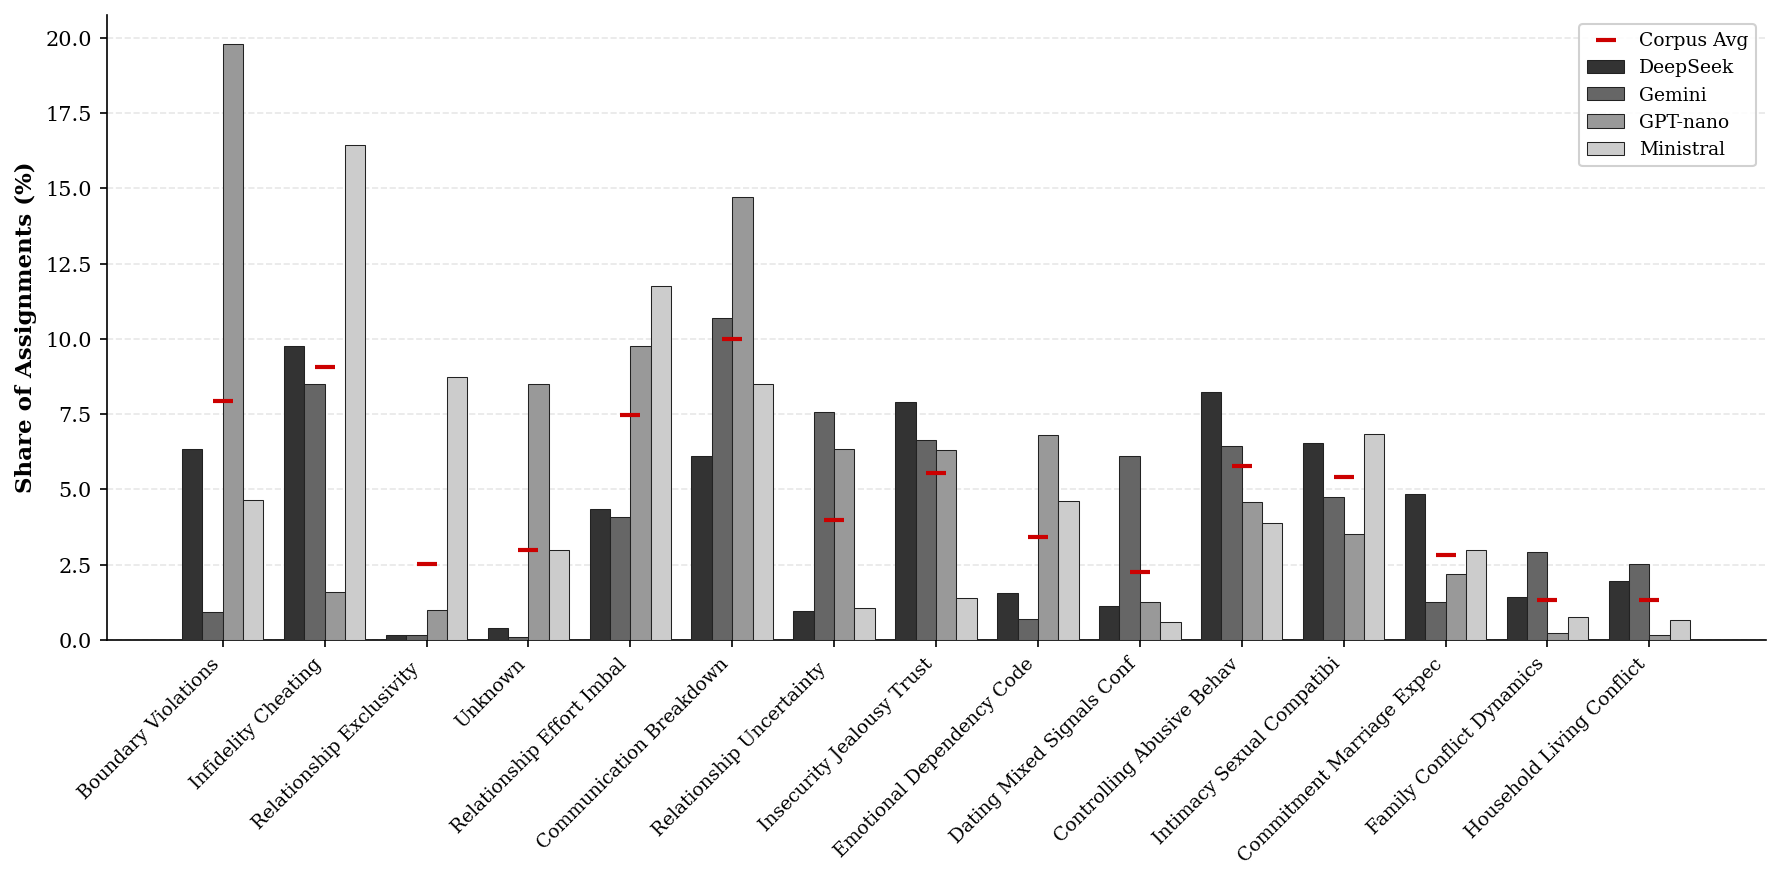

In [32]:
# Create Figure 1: Assignment Bias
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

topics = [t[0] for t in high_var_topics]
x = np.arange(len(topics))

# Use explicit model ordering and dynamic bar width to avoid overlap/hidden bars
expected_models = ['deepseek', 'gemini', 'gpt_nano', 'ministral']
model_list = [m for m in expected_models if m in model_freqs]
n_models = len(model_list)
if n_models == 0:
    raise RuntimeError('No model assignment frequencies found to plot')
width = 0.8 / n_models

model_colors_map = {'deepseek': '#333333', 'gemini': '#666666', 'gpt_nano': '#999999', 'ministral': '#cccccc'}
model_colors = [model_colors_map.get(m, '#777777') for m in model_list]

for i, model in enumerate(model_list):
    vals = [model_freqs.get(model, {}).get(t, 0) * 100 for t in topics]
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width,
                  label=SOURCE_LABELS.get(model, model.split('_')[0].title()),
                  color=model_colors[i], edgecolor='#222222', linewidth=0.5, zorder=3)

# Add corpus average markers
avg_vals = [corpus_avg.get(t, 0) * 100 for t in topics]
ax.scatter(x, avg_vals, color='#cc0000', marker='_', s=100, linewidths=2, 
           label='Corpus Avg', zorder=10)

ax.set_ylabel('Share of Assignments (%)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([clean_topic_name(t)[:25] for t in topics], 
                   rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_assignment_bias.pdf', bbox_inches='tight', dpi=300)
fig.savefig(FIGURES_DIR / 'fig_assignment_bias.png', bbox_inches='tight', dpi=300)
print('Saved: fig_assignment_bias.pdf')
plt.show()

---
## Figure 2: Topic-Conditional Norm Enforcement

Saved: fig_topic_norm_enforcement.pdf


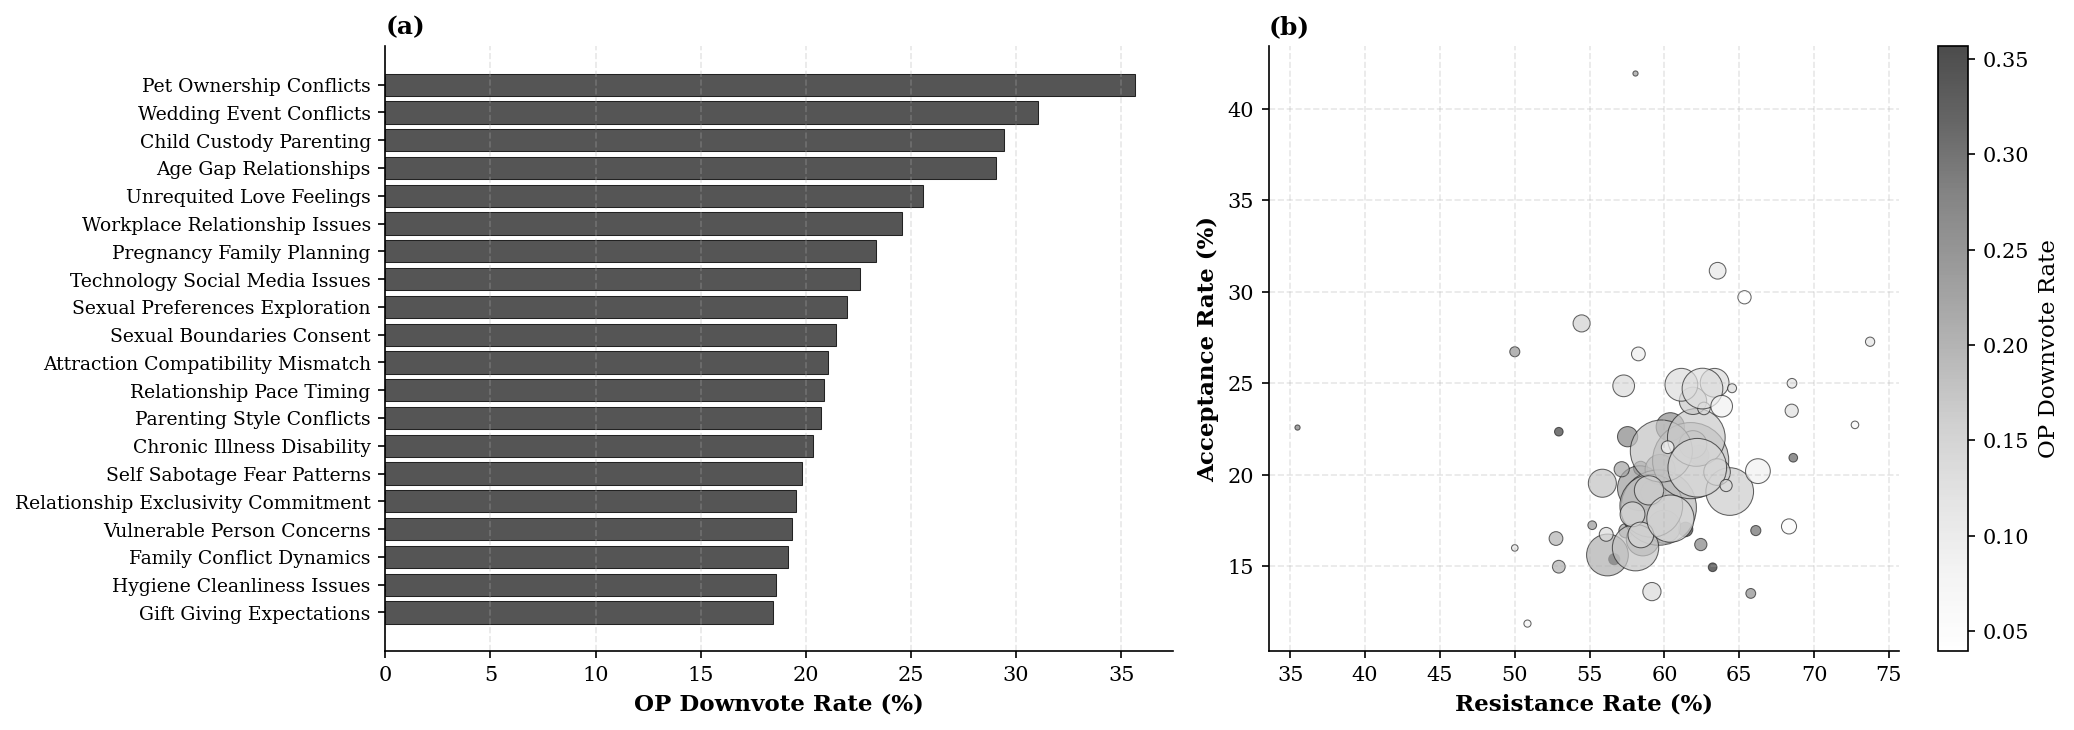

In [33]:
# Create Figure 2: Norm Enforcement (two panels)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Panel A: Top 20 strictest topics
top_strict = norm_df.nlargest(20, 'op_downvote_rate')

y = np.arange(len(top_strict))
bars = ax1.barh(y, top_strict['op_downvote_rate'] * 100, 
                color='#555555', edgecolor='#222222', linewidth=0.5)

ax1.set_yticks(y)
ax1.set_yticklabels([clean_topic_name(t)[:35] for t in top_strict['topic']], fontsize=9)
ax1.set_xlabel('OP Downvote Rate (%)', fontweight='bold')
ax1.set_title('(a)', fontweight='bold', loc='left')
ax1.invert_yaxis()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Panel B: Acceptance vs Resistance scatter
norm_plot = norm_df[norm_df['n_op_replies'] >= 30].copy()

scatter = ax2.scatter(norm_plot['resistance_rate'] * 100, 
                      norm_plot['acceptance_rate'] * 100,
                      s=norm_plot['n_op_replies'] / 5,
                      c=norm_plot['op_downvote_rate'],
                      cmap='Greys', edgecolor='#222222', linewidth=0.5,
                      alpha=0.7)

ax2.set_xlabel('Resistance Rate (%)', fontweight='bold')
ax2.set_ylabel('Acceptance Rate (%)', fontweight='bold')
ax2.set_title('(b)', fontweight='bold', loc='left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.3, linestyle='--')

cbar = plt.colorbar(scatter, ax=ax2, label='OP Downvote Rate')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_topic_norm_enforcement.pdf', bbox_inches='tight', dpi=300)
fig.savefig(FIGURES_DIR / 'fig_topic_norm_enforcement.png', bbox_inches='tight', dpi=300)
print('Saved: fig_topic_norm_enforcement.pdf')
plt.show()

---
## Figure 3: Effect Sizes (LLM vs Human)

In [34]:
# Compute effect sizes for each metric
human = metrics[metrics['source'] == 'human']

key_metrics = [
    ('n_tokens', 'Response Length'),
    ('therapy_count', 'Therapy Terms'),
    ('hedge_count', 'Hedge Words'),
    ('stay_count', 'Stay Language'),
    ('sentiment_compound', 'Sentiment'),
    ('leave_ratio', 'Leave Ratio'),
    ('modal_ratio', 'Deontic Ratio'),
    ('certainty_ratio', 'Certainty Ratio'),
    ('redflag_count', 'Red Flag Terms'),
    ('second_person_ratio', '2nd Person'),
]

effect_sizes = []
for col, label in key_metrics:
    row = {'metric': label}
    for source in ['deepseek', 'gemini', 'gpt_nano', 'ministral']:
        llm = metrics[metrics['source'] == source]
        d = cohens_d(llm[col].dropna(), human[col].dropna())
        row[source] = d
    row['mean_abs'] = np.mean([abs(row[s]) for s in ['deepseek', 'gemini', 'gpt_nano', 'ministral']])
    effect_sizes.append(row)

effect_df = pd.DataFrame(effect_sizes)
effect_df = effect_df.sort_values('mean_abs', ascending=True)
print(effect_df)

            metric  deepseek    gemini  gpt_nano  ministral  mean_abs
9       2nd Person  0.205689  0.297474  0.943250   0.688622  0.533759
8   Red Flag Terms  0.972500  0.904659  0.318315   0.204673  0.600037
7  Certainty Ratio -0.485727 -0.578656 -0.957564  -0.924499  0.736612
6    Deontic Ratio -0.652113 -0.747379 -1.065695  -0.972370  0.859389
5      Leave Ratio -0.596266 -0.704550 -1.231139  -1.339133  0.967772
4        Sentiment  0.726355  1.063940  1.489861   1.478437  1.189648
3    Stay Language  1.655754  1.730977  1.598701   2.027485  1.753229
1    Therapy Terms  1.768046  1.909177  2.209047   2.471200  2.089368
2      Hedge Words  1.834214  2.936595  2.279948   2.502392  2.388287
0  Response Length  5.937824  7.507881  4.604462   5.096708  5.786719


Saved: fig_advice_effect_sizes.pdf


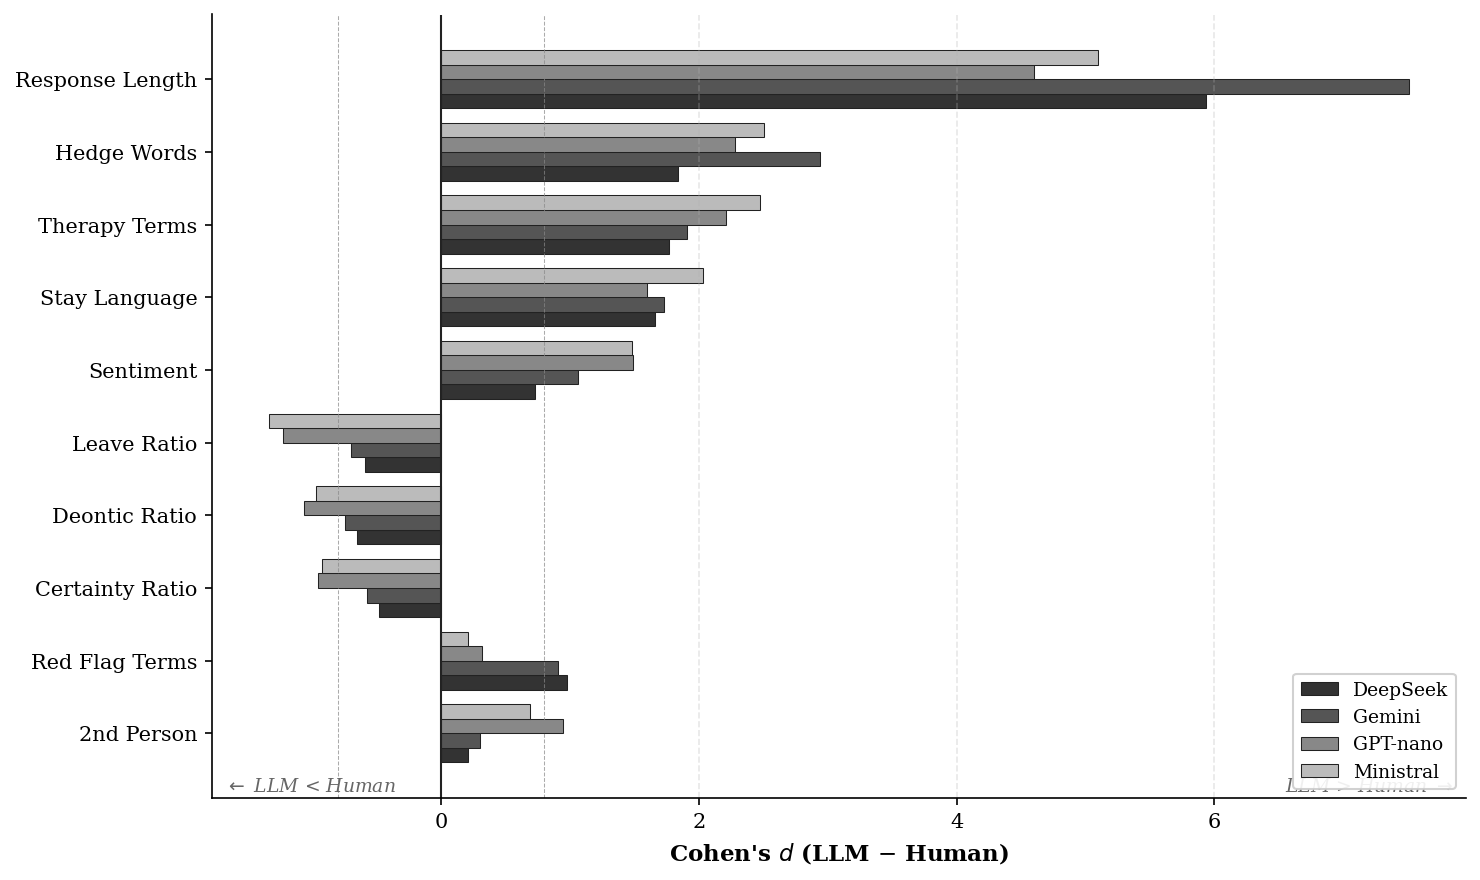

In [35]:
# Create Figure 3: Effect Sizes
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

y = np.arange(len(effect_df))
height = 0.2

llm_sources = ['deepseek', 'gemini', 'gpt_nano', 'ministral']
llm_colors = ['#333333', '#555555', '#888888', '#bbbbbb']
llm_labels = ['DeepSeek', 'Gemini', 'GPT-nano', 'Ministral']

for i, (source, color, label) in enumerate(zip(llm_sources, llm_colors, llm_labels)):
    offset = (i - 1.5) * height
    ax.barh(y + offset, effect_df[source], height, 
            color=color, edgecolor='#222222', linewidth=0.5, label=label)

ax.axvline(x=0, color='#222222', linewidth=1)
ax.axvline(x=0.8, color='#888888', linewidth=0.5, linestyle='--', alpha=0.7)
ax.axvline(x=-0.8, color='#888888', linewidth=0.5, linestyle='--', alpha=0.7)

ax.set_yticks(y)
ax.set_yticklabels(effect_df['metric'])
ax.set_xlabel("Cohen's $d$ (LLM $-$ Human)", fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add direction labels
ax.text(ax.get_xlim()[0] + 0.1, -0.8, '$\\leftarrow$ LLM < Human', 
        fontsize=9, style='italic', color='#666666')
ax.text(ax.get_xlim()[1] - 0.1, -0.8, 'LLM > Human $\\rightarrow$', 
        fontsize=9, style='italic', color='#666666', ha='right')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_advice_effect_sizes.pdf', bbox_inches='tight', dpi=300)
fig.savefig(FIGURES_DIR / 'fig_advice_effect_sizes.png', bbox_inches='tight', dpi=300)
print('Saved: fig_advice_effect_sizes.pdf')
plt.show()

---
## Figure 4: Effect Sizes by Enforcement Level

In [36]:
# Get enforcement quartiles
n_topics = len(norm_df)
strict_topics = set(norm_df.nlargest(n_topics // 4, 'op_downvote_rate')['topic'])
lenient_topics = set(norm_df.nsmallest(n_topics // 4, 'op_downvote_rate')['topic'])

def get_enforcement(topic):
    if topic in strict_topics:
        return 'strict'
    elif topic in lenient_topics:
        return 'lenient'
    return 'middle'

metrics['enforcement'] = metrics['topic'].apply(get_enforcement)
print(metrics['enforcement'].value_counts())

enforcement
middle     58320
lenient     6174
strict      5002
Name: count, dtype: int64


In [37]:
# Compute effect sizes by enforcement level
key_metrics_short = [
    ('certainty_ratio', 'Certainty'),
    ('modal_ratio', 'Deontic'),
    ('leave_ratio', 'Leave'),
    ('therapy_count', 'Therapy'),
    ('sentiment_compound', 'Sentiment'),
    ('hedge_count', 'Hedging'),
]

strict_effects = []
lenient_effects = []

for col, label in key_metrics_short:
    # Pool all LLMs
    h_strict = metrics[(metrics['source'] == 'human') & (metrics['enforcement'] == 'strict')][col].dropna()
    l_strict = metrics[(metrics['source'] != 'human') & (metrics['enforcement'] == 'strict')][col].dropna()
    d_strict = cohens_d(l_strict, h_strict)
    
    h_lenient = metrics[(metrics['source'] == 'human') & (metrics['enforcement'] == 'lenient')][col].dropna()
    l_lenient = metrics[(metrics['source'] != 'human') & (metrics['enforcement'] == 'lenient')][col].dropna()
    d_lenient = cohens_d(l_lenient, h_lenient)
    
    strict_effects.append({'metric': label, 'd': d_strict})
    lenient_effects.append({'metric': label, 'd': d_lenient})

strict_df = pd.DataFrame(strict_effects)
lenient_df = pd.DataFrame(lenient_effects)

Saved: fig_advice_enforcement_stratified.pdf


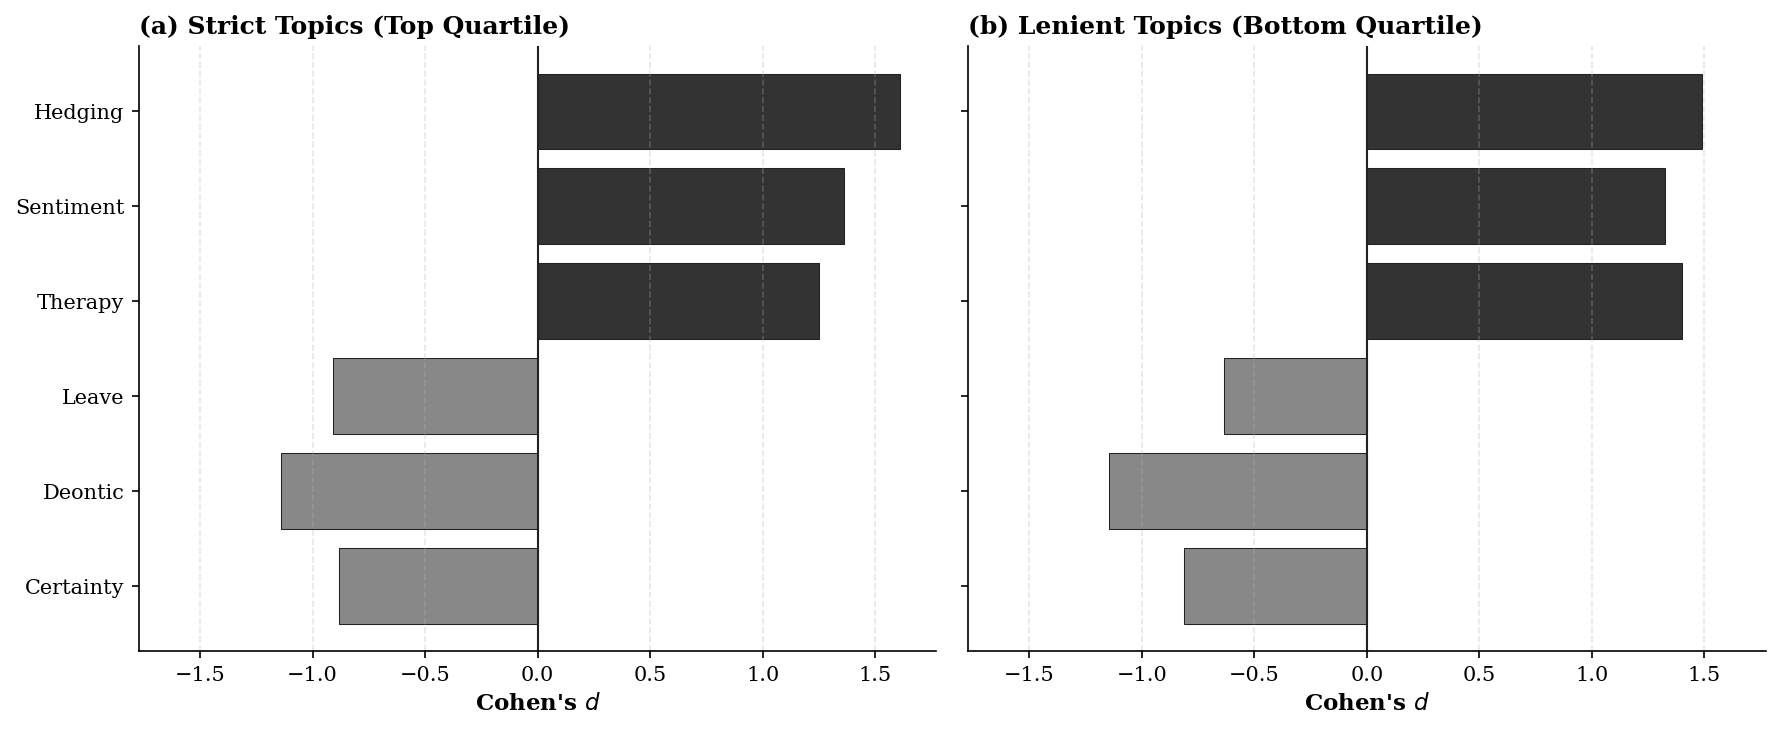

In [38]:
# Create Figure 4: Enforcement-Stratified Effect Sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150, sharey=True)

y = np.arange(len(strict_df))

# Panel A: Strict topics
colors_a = ['#333333' if d > 0 else '#888888' for d in strict_df['d']]
ax1.barh(y, strict_df['d'], color=colors_a, edgecolor='#222222', linewidth=0.5)
ax1.axvline(x=0, color='#222222', linewidth=1)
ax1.set_yticks(y)
ax1.set_yticklabels(strict_df['metric'])
ax1.set_xlabel("Cohen's $d$", fontweight='bold')
ax1.set_title('(a) Strict Topics (Top Quartile)', fontweight='bold', loc='left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Panel B: Lenient topics
colors_b = ['#333333' if d > 0 else '#888888' for d in lenient_df['d']]
ax2.barh(y, lenient_df['d'], color=colors_b, edgecolor='#222222', linewidth=0.5)
ax2.axvline(x=0, color='#222222', linewidth=1)
ax2.set_xlabel("Cohen's $d$", fontweight='bold')
ax2.set_title('(b) Lenient Topics (Bottom Quartile)', fontweight='bold', loc='left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Make x-axes symmetric
max_abs = max(abs(strict_df['d'].min()), strict_df['d'].max(),
              abs(lenient_df['d'].min()), lenient_df['d'].max()) * 1.1
ax1.set_xlim(-max_abs, max_abs)
ax2.set_xlim(-max_abs, max_abs)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_advice_enforcement_stratified.pdf', bbox_inches='tight', dpi=300)
fig.savefig(FIGURES_DIR / 'fig_advice_enforcement_stratified.png', bbox_inches='tight', dpi=300)
print('Saved: fig_advice_enforcement_stratified.pdf')
plt.show()

---
## Figure 5: Bias-Divergence Correlation

In [39]:
# Compute topic-level divergence
topic_divergence = []

for topic in metrics['topic'].dropna().unique():
    topic_data = metrics[metrics['topic'] == topic]
    human_data = topic_data[topic_data['source'] == 'human']
    llm_data = topic_data[topic_data['source'] != 'human']
    
    if len(human_data) < 10 or len(llm_data) < 40:
        continue
    
    # Mean absolute d across key metrics
    ds = []
    for col in ['certainty_ratio', 'leave_ratio', 'therapy_count', 'sentiment_compound']:
        d = cohens_d(llm_data[col].dropna(), human_data[col].dropna())
        if not np.isnan(d):
            ds.append(abs(d))
    
    if ds:
        topic_divergence.append({
            'topic': topic,
            'mean_divergence': np.mean(ds),
            'n_posts': len(human_data)
        })

div_df = pd.DataFrame(topic_divergence)

# Merge with norm enforcement
merged = div_df.merge(norm_df, on='topic')
print(f'Topics with both metrics: {len(merged)}')

Topics with both metrics: 62


Saved: fig_advice_bias_divergence.pdf


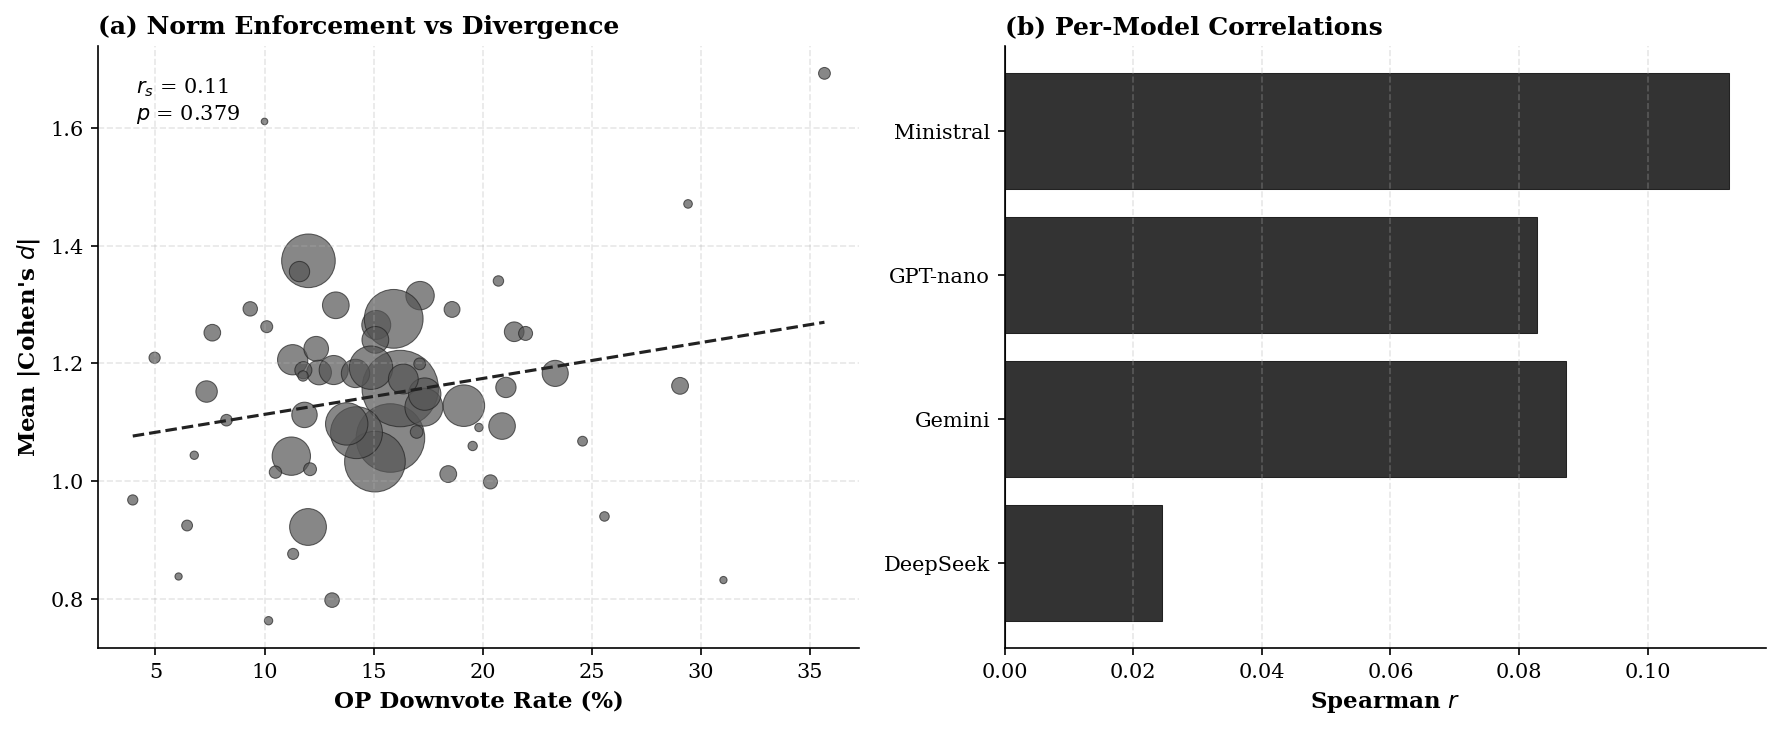

In [40]:
# Create Figure 5: Bias-Divergence scatter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# Panel A: Enforcement vs Divergence
ax1.scatter(merged['op_downvote_rate'] * 100, merged['mean_divergence'],
            s=merged['n_posts'] / 2, c='#555555', edgecolor='#222222', 
            linewidth=0.5, alpha=0.7)

# Add trend line
z = np.polyfit(merged['op_downvote_rate'], merged['mean_divergence'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged['op_downvote_rate'].min(), merged['op_downvote_rate'].max(), 100)
ax1.plot(x_line * 100, p(x_line), color='#222222', linestyle='--', linewidth=1.5)

r, pval = stats.spearmanr(merged['op_downvote_rate'], merged['mean_divergence'])
ax1.text(0.05, 0.95, f'$r_s$ = {r:.2f}\n$p$ = {pval:.3f}', 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top')

ax1.set_xlabel('OP Downvote Rate (%)', fontweight='bold')
ax1.set_ylabel('Mean |Cohen\'s $d$|', fontweight='bold')
ax1.set_title('(a) Norm Enforcement vs Divergence', fontweight='bold', loc='left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3, linestyle='--')

# Panel B: Per-model correlations
# Compute per-model correlations
model_correlations = []
for source in ['deepseek', 'gemini', 'gpt_nano', 'ministral']:
    model_div = []
    for topic in merged['topic']:
        topic_data = metrics[metrics['topic'] == topic]
        human_data = topic_data[topic_data['source'] == 'human']
        llm_data = topic_data[topic_data['source'] == source]
        
        if len(human_data) < 5 or len(llm_data) < 5:
            model_div.append(np.nan)
            continue
        
        ds = []
        for col in ['certainty_ratio', 'leave_ratio', 'therapy_count', 'sentiment_compound']:
            d = cohens_d(llm_data[col].dropna(), human_data[col].dropna())
            if not np.isnan(d):
                ds.append(abs(d))
        model_div.append(np.mean(ds) if ds else np.nan)
    
    valid_mask = ~np.isnan(model_div)
    if sum(valid_mask) > 10:
        r, p = stats.spearmanr(merged.loc[valid_mask, 'op_downvote_rate'], 
                               np.array(model_div)[valid_mask])
        model_correlations.append({'model': SOURCE_LABELS.get(source, source), 'r': r, 'p': p})

corr_df = pd.DataFrame(model_correlations)

y = np.arange(len(corr_df))
colors = ['#333333' if r > 0 else '#888888' for r in corr_df['r']]
ax2.barh(y, corr_df['r'], color=colors, edgecolor='#222222', linewidth=0.5)
ax2.axvline(x=0, color='#222222', linewidth=1)

# Add significance markers
for i, (_, row) in enumerate(corr_df.iterrows()):
    marker = '*' if row['p'] < 0.05 else ''
    ax2.text(row['r'] + 0.02 * np.sign(row['r']), i, marker, 
             fontsize=14, va='center', ha='left' if row['r'] > 0 else 'right')

ax2.set_yticks(y)
ax2.set_yticklabels(corr_df['model'])
ax2.set_xlabel('Spearman $r$', fontweight='bold')
ax2.set_title('(b) Per-Model Correlations', fontweight='bold', loc='left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_advice_bias_divergence.pdf', bbox_inches='tight', dpi=300)
fig.savefig(FIGURES_DIR / 'fig_advice_bias_divergence.png', bbox_inches='tight', dpi=300)
print('Saved: fig_advice_bias_divergence.pdf')
plt.show()

---
## Figure 6: Therapy Language Distribution

In [41]:
# Compute therapy rate per topic and source
metrics['therapy_per_100'] = (metrics['therapy_count'] / metrics['n_tokens']) * 100

therapy_by_topic = metrics.groupby(['topic', 'source'])['therapy_per_100'].mean().unstack()
therapy_by_topic = therapy_by_topic.dropna(subset=['human'])
therapy_by_topic['llm_mean'] = therapy_by_topic[['deepseek', 'gemini', 'gpt_nano', 'ministral']].mean(axis=1)
therapy_by_topic = therapy_by_topic.sort_values('human')

print(f'Topics with therapy data: {len(therapy_by_topic)}')

Topics with therapy data: 72


Saved: fig_advice_therapy_distribution.pdf


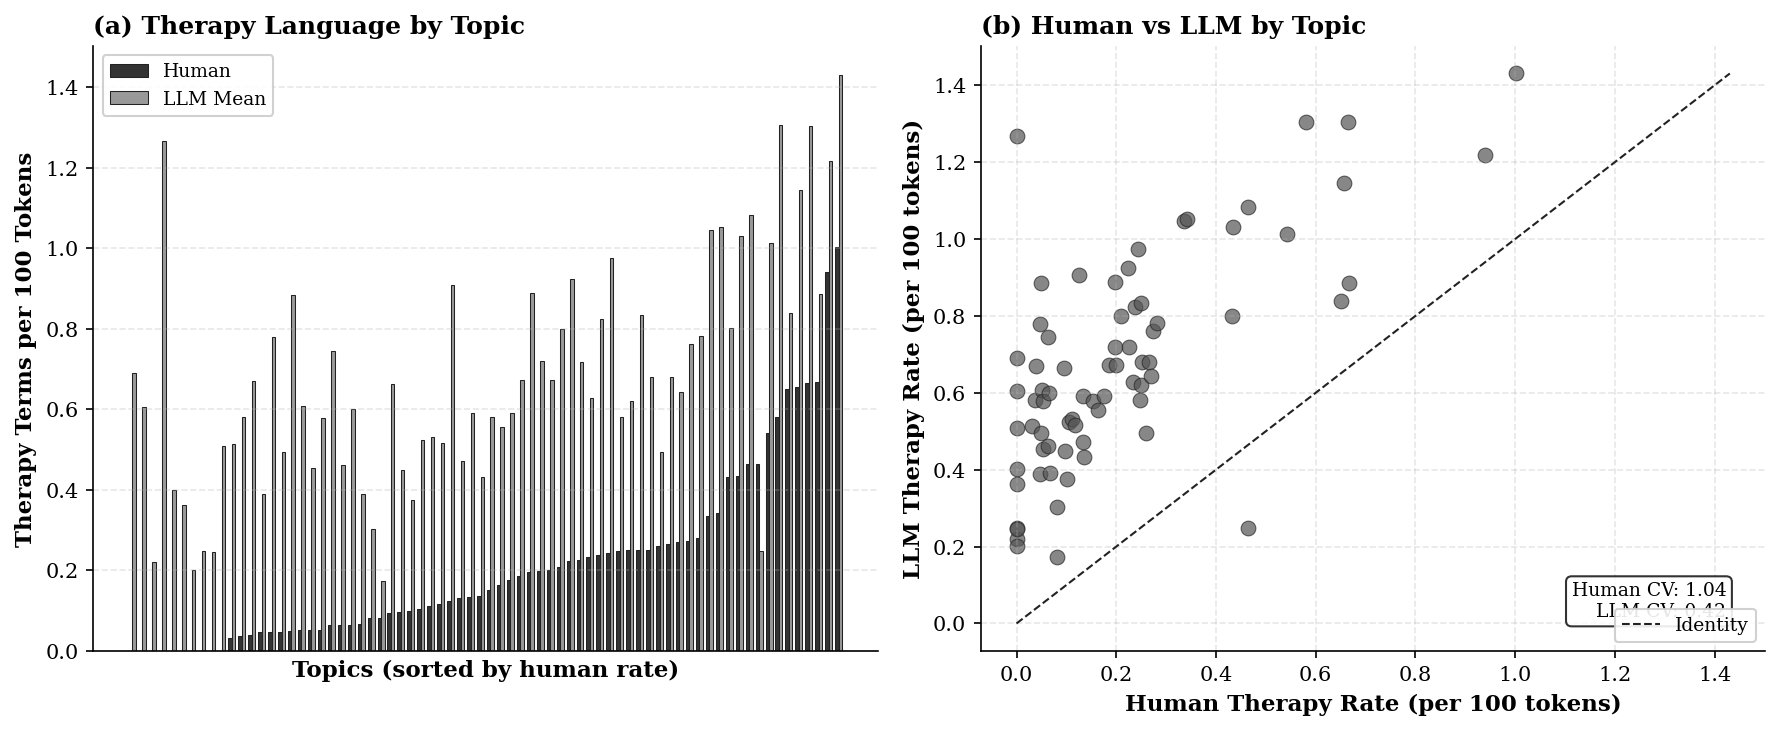

In [42]:
# Create Figure 6: Therapy Distribution (two panels)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# Panel A: Human vs LLM therapy rate by topic
x = np.arange(len(therapy_by_topic))
width = 0.35

ax1.bar(x - width/2, therapy_by_topic['human'], width, label='Human',
        color='#333333', edgecolor='#222222', linewidth=0.5)
ax1.bar(x + width/2, therapy_by_topic['llm_mean'], width, label='LLM Mean',
        color='#999999', edgecolor='#222222', linewidth=0.5)

ax1.set_xlabel('Topics (sorted by human rate)', fontweight='bold')
ax1.set_ylabel('Therapy Terms per 100 Tokens', fontweight='bold')
ax1.set_title('(a) Therapy Language by Topic', fontweight='bold', loc='left')
ax1.set_xticks([])
ax1.legend(loc='upper left', framealpha=0.9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Panel B: Scatter of human vs LLM therapy rate
ax2.scatter(therapy_by_topic['human'], therapy_by_topic['llm_mean'],
            s=50, c='#555555', edgecolor='#222222', linewidth=0.5, alpha=0.7)

# Identity line
max_val = max(therapy_by_topic['human'].max(), therapy_by_topic['llm_mean'].max())
ax2.plot([0, max_val], [0, max_val], color='#222222', linestyle='--', linewidth=1, label='Identity')

ax2.set_xlabel('Human Therapy Rate (per 100 tokens)', fontweight='bold')
ax2.set_ylabel('LLM Therapy Rate (per 100 tokens)', fontweight='bold')
ax2.set_title('(b) Human vs LLM by Topic', fontweight='bold', loc='left')
ax2.legend(loc='lower right', framealpha=0.9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.3, linestyle='--')

# Add annotation for flatter LLM profile
human_cv = therapy_by_topic['human'].std() / therapy_by_topic['human'].mean()
llm_cv = therapy_by_topic['llm_mean'].std() / therapy_by_topic['llm_mean'].mean()
ax2.text(0.95, 0.05, f'Human CV: {human_cv:.2f}\nLLM CV: {llm_cv:.2f}',
         transform=ax2.transAxes, fontsize=9, ha='right', va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_advice_therapy_distribution.pdf', bbox_inches='tight', dpi=300)
fig.savefig(FIGURES_DIR / 'fig_advice_therapy_distribution.png', bbox_inches='tight', dpi=300)
print('Saved: fig_advice_therapy_distribution.pdf')
plt.show()

---
## Summary Statistics for Paper

In [43]:
# Generate summary statistics for results.tex
print('='*70)
print('SUMMARY STATISTICS FOR PAPER')
print('='*70)

# Sample sizes
print(f"\nSample sizes:")
print(f"  Total posts: {metrics['post_id'].nunique():,}")
for source in ['human', 'deepseek', 'gemini', 'gpt_nano', 'ministral']:
    n = len(metrics[metrics['source'] == source])
    print(f"  {SOURCE_LABELS.get(source, source)}: {n:,}")

# Key metrics
print(f"\nMedian response length (tokens):")
for source in ['human', 'deepseek', 'gemini', 'gpt_nano', 'ministral']:
    med = metrics[metrics['source'] == source]['n_tokens'].median()
    print(f"  {SOURCE_LABELS.get(source, source)}: {med:.0f}")

print(f"\nLeave ratio (mean, for posts with leave/stay language):")
for source in ['human', 'deepseek', 'gemini', 'gpt_nano', 'ministral']:
    subset = metrics[(metrics['source'] == source) & 
                     ((metrics['leave_count'] > 0) | (metrics['stay_count'] > 0))]
    mean_lr = subset['leave_ratio'].mean()
    print(f"  {SOURCE_LABELS.get(source, source)}: {mean_lr:.3f}")

print(f"\nTherapy language per 100 tokens:")
for source in ['human', 'deepseek', 'gemini', 'gpt_nano', 'ministral']:
    rate = metrics[metrics['source'] == source]['therapy_per_100'].mean()
    print(f"  {SOURCE_LABELS.get(source, source)}: {rate:.3f}")

print(f"\nSentiment compound:")
for source in ['human', 'deepseek', 'gemini', 'gpt_nano', 'ministral']:
    sent = metrics[metrics['source'] == source]['sentiment_compound'].mean()
    print(f"  {SOURCE_LABELS.get(source, source)}: {sent:.3f}")

SUMMARY STATISTICS FOR PAPER

Sample sizes:
  Total posts: 11,585
  Human: 23,170
  DeepSeek: 11,575
  Gemini: 11,581
  GPT-nano: 11,585
  Ministral: 11,585

Median response length (tokens):
  Human: 82
  DeepSeek: 720
  Gemini: 1604
  GPT-nano: 579
  Ministral: 618

Leave ratio (mean, for posts with leave/stay language):
  Human: 0.694
  DeepSeek: 0.392
  Gemini: 0.361
  GPT-nano: 0.171
  Ministral: 0.177

Therapy language per 100 tokens:
  Human: 0.237
  DeepSeek: 0.472
  Gemini: 0.482
  GPT-nano: 1.104
  Ministral: 0.948

Sentiment compound:
  Human: 0.129
  DeepSeek: 0.628
  Gemini: 0.809
  GPT-nano: 0.969
  Ministral: 0.963


In [44]:
print('\n' + '='*70)
print('All figures saved to:', FIGURES_DIR.absolute())
print('='*70)


All figures saved to: /Users/tomvannuenen/Library/CloudStorage/Dropbox/GitHub/DEV/advice/notebooks/../figures
